# Salary Prediction Using Machine Learning

This project focuses on predicting an individual's salary using different personal and professional factors such as age, gender, education level, job title, and years of experience.

## Project Objective

The main objective of this project is to build a machine learning model that can predict salary based on an individual's demographic and professional information.

The target variable in this project is **Salary**.

I compared multiple regression algorithms and use cross-validation and hyperparameter tuning to find a suitable model for this dataset.

##  Tools and Technologies Used

- **Python** 
- **Pandas** 
- **NumPy** 
- **Matplotlib & Seaborn** 
- **Scikit-learn**
- **Kaggle**

### Dataset Columns

- **Age** – Age of the employee
- **Gender** – Gender of the employee
- **Education Level** – Education qualification of the employee
- **Job Title** – Job role of the employee
- **Years of Experience** – Number of years of work experience
- **Salary** – Salary of the employee and the **target variable**

## Importing Required Libraries

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [112]:
path='/kaggle/input/datasets/rkiattisak/salaly-prediction-for-beginer/Salary Data.csv'
df=pd.read_csv(path)

## Understanding the Dataset

In [113]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [114]:
df.shape

(375, 6)

In [115]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


## Handling Duplicate Records


In [117]:
df.duplicated().sum()

np.int64(50)

In [118]:
df=df.drop_duplicates()

## Handling Missing Values


In [119]:
df.isnull().sum()

Age                    1
Gender                 1
Education Level        1
Job Title              1
Years of Experience    1
Salary                 1
dtype: int64

In [120]:
df=df.dropna(subset=['Age','Gender','Education Level','Job Title','Years of Experience','Salary'])

In [121]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

## Converting Data Types

In [122]:
df['Age']=df['Age'].astype('int')

In [123]:
df['Salary']=df['Salary'].astype('int')

In [124]:
df['Years of Experience']=df['Years of Experience'].astype('int')

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  324 non-null    int64 
 1   Gender               324 non-null    object
 2   Education Level      324 non-null    object
 3   Job Title            324 non-null    object
 4   Years of Experience  324 non-null    int64 
 5   Salary               324 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 17.7+ KB


In [126]:
cat_cols=df.select_dtypes(include=('object')).columns.tolist()
num_cols=df.select_dtypes(exclude=('object')).columns.tolist()

In [127]:
print('Categorical Columns:',cat_cols)

Categorical Columns: ['Gender', 'Education Level', 'Job Title']


In [128]:
print('Numerical Columns:',num_cols)

Numerical Columns: ['Age', 'Years of Experience', 'Salary']


## Exploratory Data Analysis

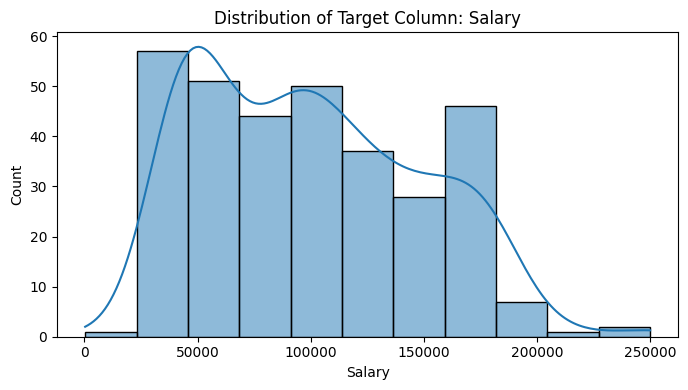

In [129]:
fig,ax=plt.subplots(figsize=(7,4))
sns.histplot(x=df['Salary'],ax=ax,kde=True)
ax.set_title("Distribution of Target Column: Salary")
plt.tight_layout()
plt.show()

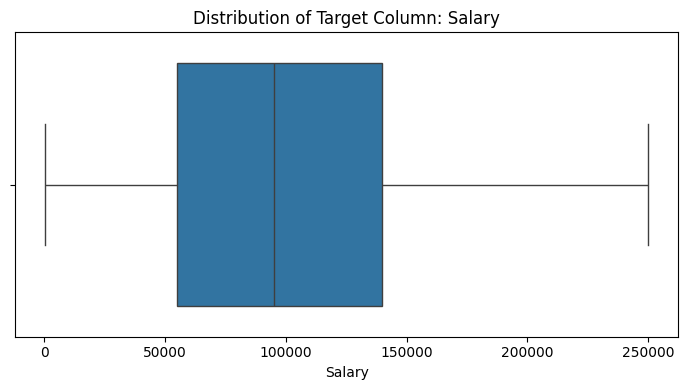

In [130]:
fig,ax=plt.subplots(figsize=(7,4))
sns.boxplot(x=df['Salary'],ax=ax,vert=False)
ax.set_title("Distribution of Target Column: Salary")
plt.tight_layout()
plt.show()

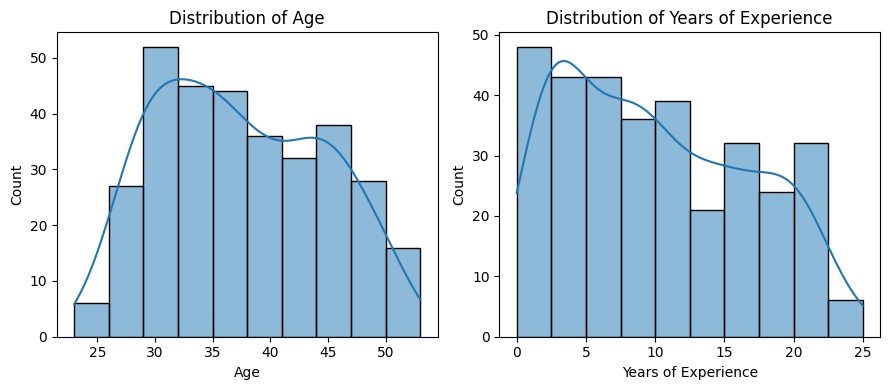

In [131]:
fig,ax=plt.subplots(1,2,figsize=(9,4))
sns.histplot(x=df['Age'],ax=ax[0],kde=True)
ax[0].set_title("Distribution of Age")
sns.histplot(x=df['Years of Experience'],ax=ax[1],kde=True)
ax[1].set_title("Distribution of Years of Experience")
plt.tight_layout()
plt.show()

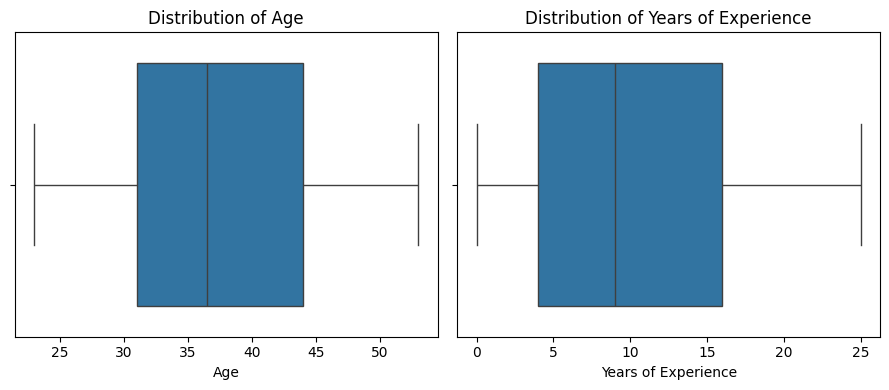

In [132]:
fig,ax=plt.subplots(1,2,figsize=(9,4))
sns.boxplot(x=df['Age'],ax=ax[0],vert=False)
ax[0].set_title("Distribution of Age")
sns.boxplot(x=df['Years of Experience'],ax=ax[1],vert=False)
ax[1].set_title("Distribution of Years of Experience")
plt.tight_layout()
plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


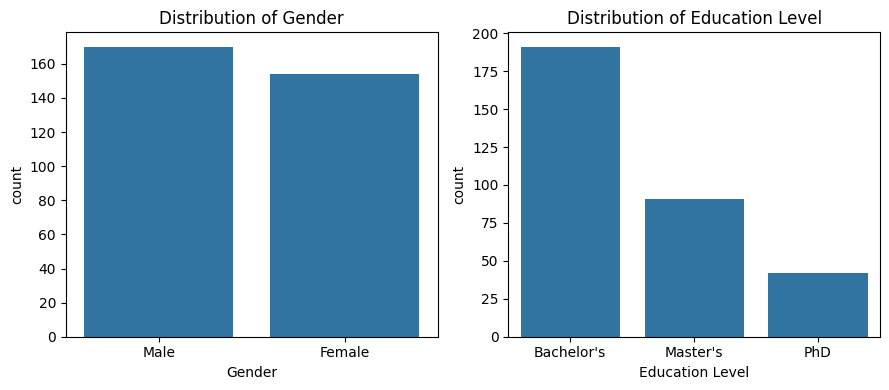

In [182]:
fig,ax=plt.subplots(1,2,figsize=(9,4))
sns.countplot(x=df['Gender'],ax=ax[0])
ax[0].set_title("Distribution of Gender")
sns.countplot(x=df['Education Level'],ax=ax[1])
ax[1].set_title("Distribution of Education Level")
plt.tight_layout()
plt.show()

In [134]:
df['Job Title'].nunique()

174

<Axes: xlabel='Gender'>

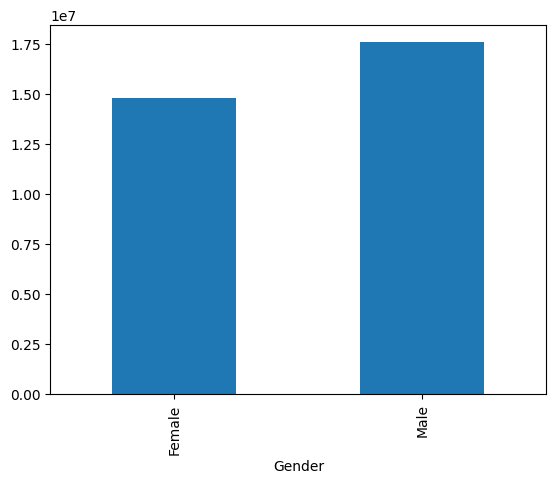

In [135]:
df.groupby('Gender')['Salary'].sum().plot(kind='bar')

<Axes: xlabel='Education Level'>

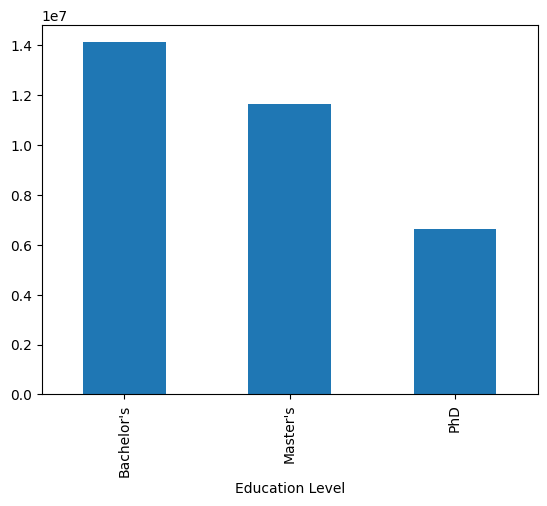

In [136]:
df.groupby('Education Level')['Salary'].sum().plot(kind='bar')

<Axes: xlabel='Job Title'>

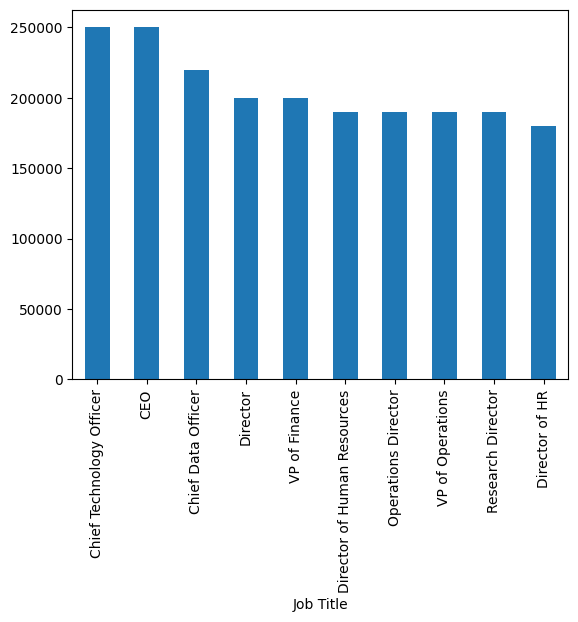

In [137]:
df.groupby('Job Title')['Salary'].max().sort_values(ascending=False).head(10).plot(kind='bar')

###  EDA Summary
Salary is different for people with different age, experience, education, and job titles.

There are also many different job titles, so we need to convert them into numbers before using them in the model.

## Data Preprocessing

In [159]:
from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

### Separating Features and Target

The target variable is **Salary**.

All remaining columns are used as input features.

In [139]:
X=df.drop('Salary',axis=1)
y=df['Salary']

### Train-Test Split

In [140]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [141]:
print(f'shape of traning data:{X_train.shape}')
print(f'shape of testing data:{X_test.shape}')

shape of traning data:(259, 5)
shape of testing data:(65, 5)


In [142]:
numerical_features=df.select_dtypes(include=[np.number]).columns.tolist()

In [143]:
categorical_features=df.select_dtypes(include=('object')).columns.tolist()

In [144]:
numerical_features.remove('Salary')

In [145]:
numerical_features

['Age', 'Years of Experience']

In [146]:
categorical_features

['Gender', 'Education Level', 'Job Title']

### Building the Preprocessing Pipeline

In [147]:
numerical_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

categorical_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    ]
)

In [148]:
preprocess=ColumnTransformer(
    transformers=[
        ('cat',categorical_transformer,categorical_features),
        ('num',numerical_transformer,numerical_features)
    ]
)

## Creating a Baseline Model

In [149]:
bl_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',LinearRegression())
    ]
)

In [150]:
bl_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Education Level',
                                                   'Job Title']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Years of Experience'])])),
                ('model', LinearRegression())])

In [151]:
bl_predictions=bl_model.predict(X_test)

### Baseline Model Evaluation

In [152]:
r2=r2_score(y_test,bl_predictions)
mae=mean_absolute_error(y_test,bl_predictions)
mse=mean_squared_error(y_test,bl_predictions)
rmse=root_mean_squared_error(y_test,bl_predictions)

In [153]:
print('r2_score:',r2)
print('mae:',mae)
print('mse:',mse)
print('rmse:',rmse)

r2_score: 0.8670754998014827
mae: 12296.63569650297
mse: 251198990.09704903
rmse: 15849.258345331147


## Comparing Multiple Regression Models

In [184]:
models={
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(random_state=42),
    'Lasso':Lasso(random_state=42),
    'RandomForestRegressor':RandomForestRegressor(random_state=42),
     'HistGradientBoostingRegressor':HistGradientBoostingRegressor(random_state=42)     
}

In [185]:
scoring={
    'r2':'r2',
    'mae':'neg_mean_absolute_error',
    'mse':'neg_mean_squared_error',
    'rmse':'neg_root_mean_squared_error'
}

##  5-Fold Cross-Validation

In [186]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=42)

In [187]:
rows=[]
for name,model in models.items():
    pipe=Pipeline(
        steps=[
            ('preprocess',preprocess),
            ('model',model)
        ]
    )
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append({
        'model':name,
        'cv_rmse':-scores['test_rmse'].mean(),
        'cv_mae':-scores['test_mae'].mean(),
        'cv_mse':-scores['test_mse'].mean(),
        'cv_r2':scores['test_r2'].mean(),
    })
    

## Cross-Validation Results

In [188]:
cv_results=pd.DataFrame(rows).sort_values('cv_rmse')
cv_results

,model,cv_rmse,cv_mae,cv_mse,cv_r2
1,Ridge,15926.363395,11480.940016,2.609378e+08,0.894532
3,RandomForestRegressor,16554.392261,11520.151081,2.858736e+08,0.885466
4,HistGradientBoostingRegressor,17555.866499,12476.859596,3.130614e+08,0.871957
2,Lasso,19652.075822,14063.131488,4.108133e+08,0.838107
0,LinearRegression,20291.154806,14658.043626,4.294386e+08,0.828906



From the results, **Ridge Regression has the lowest RMSE (15,926.36) and the highest R² (0.8945)** among the models tested.

Therefore, I Selected Ridge Regression for further hyperparameter tuning.

## Hyperparameter Tuning

In [189]:
ridge_pipe=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',Ridge(random_state=42))
    ]
)

In [190]:
param_grid={
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

In [191]:
grid=GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [192]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Gender',
                                                                          'Education '
                                                                          'Level',
                                                                          'Job '
                                                                          'Title']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Years '
                                                                          'of '
                                                                          'Experience'])])),
                                       ('model', Ridge(random_state=42))]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [193]:
print("Best alpha:", grid.best_params_['model__alpha'])
print("Best CV RMSE:", -grid.best_score_)

Best alpha: 1
Best CV RMSE: 15926.36339515253


The best alpha found is **1**.

## Retraining Final Model

In [194]:
ridge_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',Ridge(alpha=1))
    ]
)

In [195]:
ridge_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Education Level',
                                                   'Job Title']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Years of Experience'])])),
                ('model', Ridge(alpha=1))])

In [196]:
predictions=ridge_model.predict(X_test)

##  Final Model Evaluation

In [197]:
ridge_r2=r2_score(y_test,predictions)
ridge_mae=mean_absolute_error(y_test,predictions)
ridge_mse=mean_squared_error(y_test,predictions)
ridge_rmse=root_mean_squared_error(y_test,predictions)

##  Final Results

In [198]:
print('r2_score:',ridge_r2)
print('mae:',ridge_mae)
print('mse:',ridge_mse)
print('rmse:',ridge_rmse)

r2_score: 0.894940263415321
mae: 10136.729120057465
mse: 198540522.55618507
rmse: 14090.440821925518


The final Ridge Regression model achieved an **R² score of 0.8949**, meaning it explains about **89.5% of the variation in salary**.

## Conclusion

In this project, I built a machine learning model to predict employee salaries.

After comparing different models and tuning Ridge Regression, the final model achieved an **R² score of 0.8949**, explaining about **89.5% of the salary variation**.

This project helped me understand the complete machine learning workflow from **data cleaning to model evaluation**.